
---

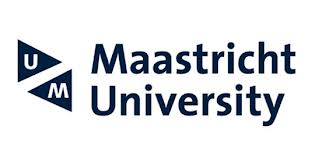

# Faculty of Science and Engineering - Department of Advanced Computer Sciences
# Course Advanced Natural Language Processing - Tutorial Tokenization

⏱️ **Estimated time:** 1.6 hours – 3.5 hours


# Advanced Natural Language Processing Course - Introduction to PyTorch
Author: Jan Scholtes and Gijs Wijngaard.
Version: 2025-2026.1

⏱️ **Estimated time:** 1.7 hours – 3.5 hours

The purpose of this notebook is to give you an introduction to the deep learning framework PyTorch. PyTorch is an open source machine learning framework originally developed by Meta that allows you to write your own neural networks and optimize them efficiently. PyTorch is not the only framework of its kind. Alternatives to PyTorch include [TensorFlow](https://www.tensorflow.org/) and [JAX](https://github.com/google/jax#quickstart-colab-in-the-cloud).

We choose to teach PyTorch as it is used often by NLP researchers; many current papers have their code published in PyTorch. PyTorch is particularly appreciated by researchers for its flexibility and for its large and active developer community. Nowadays, its the most popular framework by far in comparison to other frameworks.

If you know one machine learning framework in depth, it is very easy to transfer your skills to another, because many of these frameworks rely the same underlying concepts. For instance, TensorFlow's version 2 was heavily inspired by the most popular features of PyTorch, making the frameworks even more similar.

As a prerequisite, we recommend being familiar with the `numpy` library as most machine learning frameworks adpot a similar syntax and implement similar functions. If you are not familiar with numpy yet, don't worry: here is a [tutorial](https://numpy.org/devdocs/user/quickstart.html) to go through.
If you are already familiar with PyTorch and have created your own neural network projects, feel free to just skim through this notebook.

As an alternative to this notebook, you could go through the ["60-min blitz"](https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html) or the [Introduction](https://pytorch.org/tutorials/beginner/basics/intro.html) on the official [PyTorch website](https://pytorch.org/tutorials/).

**You do not have upload this tutorial on Canvas.** It is just meant to help you get started with PyTorch and neural networks. **Before you continue, please make a copy of this notebook (see button above) to make it editable**.


It is recommended to keep the slides from the Transformer lectures in mind when you do this tutorial, especially with respect to the dimensionalities of the different data structures in this lecture.
Comparing these to the dimensionalities for the different components of the Transformer architecture will help you understand the models better.

### Initializations

#### Environment

All code should be written in **Python 3**.
This is the default in Google Colab.

In [ ]:
!python --version

Let's now import PyTorch. Note that the package is called `torch`. The current stable version is 2.0

In [ ]:
import torch
print("Using torch", torch.__version__) # should say 2.0.1+cu118

#### Random Seed
We first start with random seed. In this way the rest of the notebook will have the same outputs on each new run of the notebook. This is nice, since in neural networks we have many stochastic functions (e.g. on initialization).
This is especially useful if you want to make your code reproducible.

## Self-Check: Things to Consider 

1. Why are the weights of a neural network usually initialized randomly instead of all set to zero?

If all weights are initialized to zero, every neuron in a given layer will compute the exact same output. During backpropagation, they will all receive the exact same gradient and update by the same amount. This prevents the network from learning complex, distinct features since all neurons will essentially evolve identically.

2. What problem arises if all weights in a neural network are initialized with the same constant value?

This leads to the symmetry problem. Just like initializing with zeros, initializing with any constant value means all hidden units connected to the same inputs will produce identical outputs and identical gradients. The network will fail to learn diverse patterns because it effectively acts as a network with only one neuron per layer.

3. Symmetry breaking means giving each neuron slightly different starting weights. Why do you think this is relevant?

Symmetry breaking is relevant because it forces neurons to start in different states. This allows them to compute different gradients and update independently during training. As a result, different neurons can specialize in detecting different patterns or features, allowing the network to utilize its full capacity.

4. Explain why random values are the best initiation of the weights in a neural network. What would be needed in addition to a standard Gaussian random function?

Random values naturally and efficiently break symmetry, ensuring that neurons learn distinct features right from the start. However, a standard Gaussian distribution (with a mean of 0 and variance of 1) is not enough on its own. You also need variance scaling based on the number of inputs (and sometimes outputs) of the layer—such as Xavier/Glorot or He initialization. Without this scaling, activations and gradients can exponentially shrink (vanish) or grow (explode) as they pass through deep networks.









Aswers: 

In [ ]:
torch.rand(1)  # this value will change each time you run the notebook

In [ ]:
torch.manual_seed(42)

Let's generate a random value.

In [ ]:
torch.rand(1)  # this value will remain the same each time you run the notebook

If you restart the runtime of your notebook and run again the cells above, you'll notice that you only get the same value if you first set the random seed.

## Tensors

Tensors are the PyTorch equivalent of NumPy arrays, but they can additionally be used on a GPU for faster calculations. The word "tensor" is a generalisation of concepts you could already know from linear algebra. For instance, a vector is a 1-D tensor, and a matrix is a 2-D tensor.

Working with PyTorch, we will use tensors of various shapes and number of dimensions. The most simple way to create a tensor is to call `torch.Tensor` passing the desired shape as an argument:




In [ ]:
x = torch.Tensor(2, 3, 3) # We create a 2 by 3 by 3 dimensions tensor
print(x)

You can of course also initialise a tensor with the values you want. The following methods allow you to do so.

* `torch.zeros`: Creates a tensor filled with zeros
* `torch.ones`: Creates a tensor filled with ones
* `torch.rand`: Creates a tensor with random values uniformly sampled between 0 and 1
* `torch.randn`: Creates a tensor with random values sampled from a normal distribution with mean 0 and variance 1
* `torch.arange`: Creates a tensor containing the values $N,N+1,N+2,...,M$

In [ ]:
# Randomly initialise a 2-D tensor (a matrix)
x = torch.rand(4, 3)
print(x)

There are multiple ways to obtain the shape of a tensor:

In [ ]:
x = torch.Tensor([[0, 1, 2], [3, 4, 5]])
print(x)

print(x.size())  # default
print(x.shape)   # numpy style

In [ ]:
# or you can check the number of dimensions...
print('Number of dimensions:', x.dim())

# and store them in separate variables
dim1, dim2 = x.size()
print('Size of the dimensions:', dim1, dim2)

Here’s a visual heatmap of the two random 4×3 tensors x and y.

Each cell’s color shows the value (darker = higher).

This is useful to see the structure and randomness at a glance.



In [ ]:
import torch
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(x, cmap="Blues", aspect="auto")
axes[0].set_title("x = torch.rand(4,3)")
axes[0].set_xticks(range(3))
axes[0].set_yticks(range(4))

axes[1].imshow(y, cmap="Greens", aspect="auto")
axes[1].set_title("y = torch.rand(4,3)")
axes[1].set_xticks(range(3))
axes[1].set_yticks(range(4))

plt.tight_layout()
plt.show()

### Operations

A full list of operations can be found at https://pytorch.org/docs/stable/index.html. We will review the most important ones here.

#### Adding

In [ ]:
# You can add tensors in many ways.
# The easiest is to simply use a python + operator:
x = torch.rand(4, 3)
y = torch.rand(4, 3)
print(x + y)

# But you can also use torch.add:
print(torch.add(x, y))

# Provide an output Tensor and save the result there:
result = torch.Tensor(4, 3)
torch.add(x, y, out=result)
print(result)

# Or add in-place (this changes y!)
# Note: Any operation that mutates a tensor in-place is post-fixed with an "_", like "add_" here.
y.add_(x)
print(y)

Similarly, you have various other basic arithmetic operations in PyTorch:


In [ ]:
# Division
x = torch.rand(4, 3)
y = torch.rand(4, 3)
print("Division 1:", x / y)  # Division using the / operator
result = torch.div(x, y)  # Division using torch.div
print("Division 2", result)

# Modulo
x = torch.tensor([10, 20, 30, 40])
y = torch.tensor([3, 5, 7, 9])
print("Modulo 1:", x % y)  # Modulo using the % operator
result = torch.fmod(x, y)  # Modulo using torch.fmod
print("Modulo 2:", result)

# Floor Division
x = torch.tensor([10, 20, 30, 40])
y = torch.tensor([3, 5, 7, 9])
print("Floor division 1:", x // y) # Floor division using the // operator
result = torch.floor_divide(x, y) # Floor division using torch.floor_divide
print("Floor division 2:", result)

# Element-wise Multiplication
x = torch.rand(4, 3)
y = torch.rand(4, 3)
print("Multiplication 1:", x * y)  # Multiplication using the * operator
result = torch.mul(x, y)  # Multiplication using torch.mul
print("Multiplication 2:", result)

# Dot Product (Vector Inner Product)
x = torch.tensor([1, 2, 3])
y = torch.tensor([4, 5, 6])
result = torch.dot(x, y)
print("Dot product:", result)

# Matrix Multiplication
A = torch.rand(4, 3)
B = torch.rand(3, 2)
print("Matmul 1:", A @ B)
result = torch.mm(A, B)  # Matrix multiplication using torch.mm
print("Matmul 2:", result)
result = torch.matmul(A, B)  # Matrix multiplication using torch.matmul (which allows broadcasting)
print("Matmul 3:", result)

This is of course not all the mathematical operations out there.

### Weights in a Neural Network

Let's talk about the last operation from above, matrix multiplication. This operation is used everywhere in neural networks. Most of the time, we have a input vector $x$, which we matrix multiply against a weight $W$. In neural networks, we learn this weight $W$ on backpropagation.

This is also why neural networks are often trained on GPU's. These GPU's are much faster in computation of matrix multiplications than CPU's, which results in great speed improvements.

In [ ]:
# Let's create a tensor x with shape 2x3 (aka a 2x3 matrix)
x = torch.rand(2, 3)
print(x)
print(x.shape)

In [ ]:
# Now, let's create a square matrix W with shape 3x4
W = torch.rand(3, 4)
print(W)

In [ ]:
# Now we can perform matrix multiplication, since we have 2x3 and 3x3 matrices!
h = x @ W
print(h)
print(h.shape)

You can only do the operation if the last dimension of the tensor you have on the left side of the operator is the same as the first operation you have on the right side (in this case 3 == 3).

We get as output the first dimension of the first tensor, and the last dimension of the second tensor (in our case, 2 by 4).

### Reshaping

Quite often you will have the problem that the dimensions of your Tensors don't match, you will have a problem like this (the following code should return a RuntimeError!).

In NLP, reshaping occurrs mostly to match the length of (variable length) input sequences or combining subword embeddings. Other applications are related to masking or loss-functions, which expect tensors to be in very specific shapes.

In [ ]:
%%script --no-raise-error python
import torch
x = torch.rand(2,2)
W = torch.rand(1,2)
x @ W

Sometimes this means we have to reshape our tensor we can do this with `.reshape()`:

In [ ]:
x = torch.rand(2,2)
W = torch.rand(1,2)
x = x.reshape(-1, 1) # The -1 means put the rest of the dimensions all together here
print(x.size())
x @ W

Another solution that you might see often is that we have to create another dimension with `.unsqueeze()` for the Tensor to fit:

In [ ]:
x = torch.rand(2,2)
x = x.unsqueeze(-1)
print(x.size()) # Our vector is now 2 by 2 by 1
x @ W

Reduction of dimensions would not work as reduction functions will trow information away. This is why we use reshaping. The code below shows the difference between reshaping and reducing.

In [ ]:
import torch

# Create a small example tensor
x = torch.arange(6)  # [0,1,2,3,4,5]
print("Original x:", x)
print("Shape:", x.shape)

# --- Reshape ---
reshaped = x.reshape(2, 3)
print("\nReshaped to (2,3):\n", reshaped)
print("Still contains the same numbers, just arranged differently.")

# --- Flatten back ---
flattened = reshaped.reshape(-1)
print("\nFlattened back:", flattened)

# --- Reduction operation (loses info) ---
# Convert to float before calculating the mean
mean_val = reshaped.float().mean(dim=1)  # take mean over columns
print("\nMean along each row (information reduced):", mean_val)

# --- Summing (also loses info) ---
sum_val = reshaped.sum()
print("Sum of all elements (single number):", sum_val)

### Indexing
It is also quite common that you will need to select a part of a tensor. This works just the same as it would with NumPy:

In [ ]:
print('result[:, 1]', result[:, 1])      # second column
print('result[0]', result[0])            # first row
print('result[:2, -1]', result[:2, -1])  # first two rows, last column
print('result[1:3, :]', result[1:3, :])  # middle two rows
print('result', result)

## Automatic computation of gradients
Now one of the reasons that PyTorch is so useful is because of that we can easily get the gradients/derivatives of any function that we compute. This is essentially handy when using the weights in a neural network, since on backpropagation we can calculate how much we should change each weight so that next time we run the neural network we learn to predict a bit closer to the actual value.

To do this fast, PyTorch keeps track of a computational graph, which helps us see how we get from output of a neural network all the way back to the input. So we only need to compute everything on the forward step of the function, the backpropagation is handled automatically by PyTorch.


### Enabling automatic gradients

In order to let PyTorch compute its gradient, a Tensor needs to have its `requires_grad` property set to `True`. This is set to False by default.


In [ ]:
t = torch.ones(3)
t.requires_grad = True
t

In [ ]:
t = torch.ones(3, requires_grad=True) # Or in 1 step
t


### Example

Let's go over a forward step of how a computation is done in PyTorch. We start with a input vector $x$.

In [ ]:
# create an input vector x
x = torch.ones(3, requires_grad=True)
print(x)

In [ ]:
# Now we define our function
# Note that, even though x is a vector, we can still add a scalar value to it.
# PyTorch will just add that value to each element of the vector.
y = (x + 2)**2 + 3
print(y)

In [ ]:
# y has a gradient function 'grad_fn' since it was created by an operation (cell above).
# This grad_fn will be used by PyTorch for obtaining the gradient
print(y.grad_fn)

In [ ]:
# Our final output o is the mean
o = y.mean()
print(o)

In [ ]:
# now we can take the gradients by calling o.backward()
# this will populate x.grad
o.backward()

`x.grad` will now contain the gradient $\partial o/ \partial x$, which expresses how a change in $x$ will affect output $o$:

In [ ]:
print(x.grad)

## NN module

Now if we want to build a large neural network, we could define all our Tensors like above (with `require_grad=True`), however this would require a lot of excess code, that we would not necessarily want. By Using the `torch.nn` environment, we have a more easy framework to calculate gradients and adjust the parameters.

Let's define a very simple neural network to perform linear regression for us. We can do this by defining a `torch.nn.Linear()` function.

At the most basic level, a single neuron in a neural network calculates a simple formula you might remember from algebra: $y = wx + b$. In this formula, $w$ is the weight, $x$ is the input data, and $b$ is the bias.

Here is the role each plays in helping the network learn:

1. Weights: The "Importance" Factor
Role: Weights determine how much influence a specific input has on the neuron's output.Explanation: Imagine you are deciding whether to buy a car. The car's price, mileage, and color are your inputs. You probably care a lot more about the price than the color. In a neural network, the "price" input would be assigned a large weight (strong influence), and the "color" input would be assigned a small weight (weak influence).

Visually, if you are graphing the neuron's output, changing the weight changes the slope (or steepness) of the line. It dictates how fast the neuron reacts to changes in the input.

2. Biases: The "Flexibility" Factor
Role: Biases act as an independent threshold that shifts the neuron's activation point.
Explanation: Let's go back to the car example. Even if the price and mileage are perfect (great inputs multiplied by great weights), you might just have a baseline reluctance to buy any car right now because you are trying to save money. A bias is like that baseline assumption. It allows the neuron to say, "The inputs need to pass this specific threshold before I 'fire' or output a strong signal."
Visually, the bias shifts the entire curve left or right (or up and down). Without a bias, a neural network's decision line is forced to pass exactly through the origin point $(0,0)$. This is incredibly limiting. The bias gives the network the freedom to move that line wherever it needs to go to properly fit the data.

In [ ]:
model = torch.nn.Linear(10, 2)
model

These are the weights $W$ and bias $b$ of our model. We basically do the operation $xW + b$.

In [ ]:
model.weight

In [ ]:
model.bias

Let's define an input $x$, which has a size of 4 (e.g. batch size) by 10 items.

In [ ]:
x = torch.rand(4, 10)
x

To get the output, we simply put in $x$ as a argument to our model function. Whats happens under the hood is that each `torch.nn` module has a `forward()` function that we call when we pass our data as the argument.

In [ ]:
output = model(x)

Now, to compute the results of the neural network, we need two things.
We first start with the labels, which we use to compute our output to. We basically want our network to predict these for us. If trained correctly, on each training step the network moves its weights a bit more towards predicting these correctly. These labels need to be integers (see dtype).

In [ ]:
labels = torch.tensor([0, 1, 0, 1])
labels

Another important component is the loss function. This function we use to compute the difference between the labels and our prediction/output. The lower our loss function value is, the closer our scores are towards predicting the outputs correctly. But **be aware**! This is not a metric to evaluate our model's performance on! You can not compare one's model losses against a different model's loss.

We use a cross-entropy loss, which is used a lot in natural language processing. But there are essentially a lot of different types of loss functions you can use. These loss functions allow the model to learn from our labels.

In [ ]:
loss_func = torch.nn.CrossEntropyLoss()

Now we can compute our result. We pass the labels and the output to our loss function to calculate the loss. This loss we then backpropagate through the model.

In [ ]:
loss = loss_func(output, labels)
loss

### Cross Entropy versus Mean Squared Error

Cross-Entropy is the go-to loss function in Natural Language Processing (NLP), Mean Squared Error (MSE) gets left behind.

To understand this, we need to look at what an NLP model is actually trying to do compared to other types of machine learning.
1. The Goal: Classification vs. Regression

In NLP, the most common task is classification. When a model like GPT predicts the next word in a sentence, it is looking at a massive dictionary (vocabulary) of, say, 50,000 words. It has to assign a probability to every single word and pick the one with the highest chance of being correct. It is sorting data into categories.

Mean Squared Error (MSE) is built for regression—predicting continuous, flowing numbers like house prices or the temperature.

2. Why Mean Squared Error (MSE) Fails in NLP
If you are predicting a house price, and the real price is $300,000, predicting $299,000 is a great guess. The "distance" between the numbers matters.
Words don't work like that. If the correct word is "apple", predicting "banana" isn't "closer" than predicting "car". They are just different discrete categories. MSE tries to measure the physical distance between predictions, which makes no sense for a list of words.
Furthermore, MSE has a learning problem when dealing with probabilities (numbers between 0 and 1). If a model is completely, entirely wrong, MSE caps the maximum error at 1 (since $1^2 = 1$). Because the error curve is so flat, the model receives very little urgency (gradient) to fix its mistake. It learns incredibly slowly.

3. Why Cross-Entropy Wins
Cross-Entropy is explicitly designed to compare probability distributions. It measures how well the model's assigned probabilities match the actual truth.
Its superpower lies in how it penalizes mistakes using logarithms. If the model is 99% confident the next word is "apple" and it is "apple", the loss is almost zero. But if the model is 99% confident the word is "car" and it's actually "apple", Cross-Entropy doesn't just slap its wrist—it hands out a massive, exponential penalty.
This steep penalty for being confidently wrong creates a very strong "learning signal" (gradient). It forces the network to rapidly adjust its weights to fix the mistake.

### Backpropagation
We propagate backwards with `.backward()`:

In [ ]:
loss.backward()

We now have populated the gradients. To access the gradients, we can use `.grad`:

In [ ]:
model.weight.grad

#### Manually
Now we need to update the weights and biases to reflect the changes on backpropagation. We don't want to change too much into a new direction: we want to do smaller steps so that we can divert into a optimal minimum, something that we call Gradient Descent. We do this by setting a learning rate:

In [ ]:
learning_rate = 0.1
model.weight.data = model.weight.data - model.weight.grad.data * learning_rate
model.bias.data = model.bias.data - model.bias.grad.data * learning_rate

This is one single step that we do each time we train a model! To train a neural network on any classification task, we do this thousands of times. We collect a lot of data and train the model for multiple rounds (epochs).

Now instead of setting all our new weights and biases manually, we do this by defining an optimizer. We define what parameters we want to let the optimizer update, and define a learning rate of how much the gradients should be weighted into changing the parameters.

There exists various different optimizers, the most popular ones nowadays are [SGD](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html#torch.optim.SGD), [Adam](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html#torch.optim.Adam) and [AdamW](https://pytorch.org/docs/stable/generated/torch.optim.AdamW.html#torch.optim.AdamW).

#### Using torch.optim

We just did a step of gradient descent manually, but in practice we would use an optimizer provided by PyTorch, from [torch.optim](https://pytorch.org/docs/stable/optim.html). The simplest one does exactly the same as what we just did.

Let's do the same update again, but now using the built-in stochastic gradient descent (SGD) from PyTorch. Remember to zero-out all gradient tensors with `zero_grad`. Be aware that on each step in a training loop, we have to reset the gradients to allow for a new ones (with `.zero_grad()`. We update the weights with `optimizer.step()`.


PyTorch accumulates gradients by default, so you must clear them each iteration before computing the next batch’s gradients; then optimizer.step() uses the current gradients (plus any optimizer state like momentum) to update the weights. so:

1.   zero_grad(): prevents old gradients from contaminating the next step.
2.   backward(): computes gradients for this forward pass and adds them to .grad.
3.   step(): uses .grad (and optimizer state) to move parameters and then you repeat.

In [ ]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

output = model(x)

# loss
loss = loss_func(output, labels)

model.zero_grad()    # reset gradients
loss.backward()  # compute gradients

# adjust weights using the optimizer
optimizer.step()

# compute new output after updating
new_out = model(x)
new_loss = loss_func(new_out, labels)

print("target:", labels)
print("out:", output)
print("new out (should be closer to target):", new_out)

print("\nloss:", loss)
print("new loss (should be lower):", new_loss)

## Models

Now instead of a single linear layer, we often have way more complex models that we use to learn. There are multiple ways to define these. One is by just having a list of models together. For example using `ModuleList` or `Sequential`:

In [ ]:
model = torch.nn.ModuleList([
    torch.nn.Linear(10, 5),  # Input layer to hidden layer
    torch.nn.ReLU(),        # Activation function
    torch.nn.Linear(5, 2)  # Hidden layer to output layer
])
out = x
for module in model:
    out = module(out)
print(out)

In [ ]:
model = torch.nn.Sequential(
    torch.nn.Linear(10, 5),
    torch.nn.ReLU(),
    torch.nn.Linear(5, 2)
)
print(model(x))

As you can see, we have a non-linearity (activation function) in between the two linear layers. In this way, we allow the network to learn more complex patterns. Also, if we don't add non-linearities in between our fully-connected layers, they can be deduced to a single layer: the composition of multiple linear transformations is equal to a single different linear transformation. For example, if our input is $2$, and the weights are $5$ of $2$ layers, then $2 \times 5 \times 5$. This is equal to if we have 1 layer of $25$, ($2 \times 25$).

Some of the most popular non-linearities include `ReLU`, `GELU`, `Sigmoid` and `Tanh`.

---

A transformer block has two main places where a nonlinearity appears:

*   Inside the Feed-Forward Network (FFN)
*   (Sometimes) inside gating mechanisms or output projections.

Early Transformers (e.g. original Vaswani et al., 2017) used ReLU in the FFN. Still a reasonable default when you want speed and simplicity. Modern LLMs use mostly GELU. Sigmoid and Tanh are not used or very rare in FFN.


GELU = ReLU + smooth probabilistic gating.
It keeps the strong gradients and efficiency of ReLU while avoiding its hard zero cut-off.
In practice, large NLP models (BERT, GPT family) found it trains faster, more stably, and with slightly better accuracy, so it became the default.

The most used configuration is that we inherit the `torch.nn.Module` class. With class inheritance we allow all properties of that class and we can overwrite specific functions ourselves (e.g. the `.forward()` function).

Instead of defining the non-linearity as a class, we could also define is as a functional function with `torch.nn.funtional` (often imported as `F`). This is because a activation function does not have learnable parameters, but are merely stateless functions.

In [ ]:
import torch.nn.functional as F
class CustomModel(torch.nn.Module):
    def __init__(self):
        super().__init__() # With this function we inherit all information from the torch.nn.Module class

        # Here we normally define our layers
        self.linear1 = torch.nn.Linear(10, 5)
        self.linear2 = torch.nn.Linear(5, 2)

    def forward(self, x): # This function is called when we pass the data as argument to the model (e.g. model(x))
        x = self.linear1(x)
        x = F.relu(x)
        x = self.linear2(x)
        return x

In [ ]:
model = CustomModel()

In [ ]:
model(x)

### Training
Again, to train these models, we again use the `zero_grad()`, `backward()` and `step()` functions. In summary:

In [ ]:
# Randomly initialize data and labels
data = torch.rand(100, 10)
labels = torch.randint(0, 2, (100,))

In [ ]:
# Define our helper loss and optimizer functions
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Set number of epochs, this is how many times we iterate over the dataset
num_epochs = 5
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(data)

    # Compute the loss
    loss = criterion(outputs, labels)

    # Backpropagation and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item()}')


## Dataset Modules
Now there are a couple more functions that are essential to use for training neural networks. Specifically on the data side you will often see two classes used, `Dataset` and `DataLoader`. Say we have a dataset like this:

In [ ]:
sentences = ["this is a sentence for label 0", "this is a sentence for label 1"]
labels = [0, 1]
data = list(zip(sentences, labels))

### Dataset
Now let's define our Dataset. We do this by inheriting the Dataset class.

Our datasets needs to have at least 3 functions.
1. The `__init__` function that is invoked when we call the class, we pass our data here to store it inside the dataset class.
2. The `__len__` function is used to return the length of the full dataset, this is needed by our dataloader later on to calculate how long it takes to go through one epoch.
3. The `__getitem__` function is used to return a single item in our dataset. When we iterate over our dataset, we basically iterate over the length and return each item one by one.

In [ ]:
class SimpleDataset(torch.utils.data.Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

In [ ]:
dataset = SimpleDataset(data)
dataset

By indexing the dataset we get a specific item:

In [ ]:
dataset[1]

### DataLoader
Now we have to use a `DataLoader` to iterate over the dataset when training. With DataLoader, we can specify how many items we want to process at once (batch processing). With for example a batch size of 8, per iteration we return a list of tuples, where each tuple is each class times the batch size:

In [ ]:
train_data = torch.utils.data.DataLoader(dataset, batch_size=2)
inputs, labels = next(iter(train_data))
print("All inputs (2x):", inputs)
print()
print("All labels (2x):", labels)

 One thing that you often see used as well is a `collate_fn` function. This function is there to preprocess and make sure the batched data can be concatenated together. This is often a problem when dealing with tensors, as each item in a tensor has to be the same length to represent it in a single tensor. For example for processing text, we need to implement is as numbers and create a tensor to be able to process the data.

In [ ]:
dictionary = {"this": 1., "is": 2., "a": 3., "sentence": 4., "for": 5., "label": 6., "0": 7., "1": 8.}
def collate_fn(batch):
    inputs = torch.tensor([[dictionary[word] for word in item[0].split()] for item in batch])
    targets = torch.tensor([item[1] for item in batch])
    return inputs, targets

In [ ]:
train_data = torch.utils.data.DataLoader(dataset, batch_size=2, collate_fn=collate_fn)
inputs, labels = next(iter(train_data))
print("All inputs (2x):", inputs)
print()
print("All labels (2x):", labels)

We use this `DataLoader` to loop over the data to train:

In [ ]:
model = torch.nn.Linear(7, 2)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
for epoch in range(num_epochs):
    for inputs, labels in train_data: # We use the data loader to loop over the dataset
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item()}')

Now you've learned the basics of how to use PyTorch. In the following tutorials you will see many of these components being used.

## Using GPU Acceleration

One of the key advantages of PyTorch is its seamless GPU support. GPUs can perform matrix operations much faster than CPUs, which is essential when training large neural networks.

To use a GPU in PyTorch, you need to:
1. Check if a GPU is available
2. Create a **device** object
3. Move your model and data to that device

This pattern is used in virtually every PyTorch project you'll encounter.

In [ ]:
# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# You can also check for Apple Silicon GPU (MPS)
if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
    print(f"Apple Silicon GPU available, using: {device}")

To move a model and data to the device, use `.to(device)`:

In [ ]:
# Move model to device
model = torch.nn.Linear(10, 2).to(device)

# Move data to device
x = torch.rand(4, 10).to(device)
labels = torch.tensor([0, 1, 0, 1]).to(device)

# Now computation happens on the GPU (if available)
output = model(x)
print(f"Model device: {next(model.parameters()).device}")
print(f"Input device: {x.device}")
print(f"Output device: {output.device}")

**Important:** Both the model and the data must be on the same device. If you try to compute with tensors on different devices, PyTorch will raise a `RuntimeError`.

When working in Google Colab, you can enable GPU via **Runtime → Change runtime type → GPU**.

## Saving and Loading Models

After training a model, you'll want to save it so you can reuse it later without retraining. PyTorch provides two main approaches:

1. **Save the state dict** (recommended): saves only the learned parameters
2. **Save the entire model**: saves the model architecture + parameters

The state dict approach is preferred because it is more flexible and portable.

In [ ]:
# Define and "train" a simple model
model = CustomModel()

# Save the state dict (recommended approach)
torch.save(model.state_dict(), 'model_weights.pth')
print("Model saved!")

# Load the state dict into a new model instance
loaded_model = CustomModel()
loaded_model.load_state_dict(torch.load('model_weights.pth', weights_only=True))
loaded_model.eval()  # Set to evaluation mode
print("Model loaded!")

# Verify the weights are the same
for (n1, p1), (n2, p2) in zip(model.named_parameters(), loaded_model.named_parameters()):
    assert torch.equal(p1, p2), f"Mismatch in {n1}"
print("All weights match!")

You can also save and load **checkpoints** that include the optimizer state, epoch number, and loss — useful for resuming training:

In [ ]:
# Save a training checkpoint
checkpoint = {
    'epoch': 5,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': 0.42,
}
torch.save(checkpoint, 'checkpoint.pth')

# Load checkpoint
checkpoint = torch.load('checkpoint.pth', weights_only=False)
model = CustomModel()
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Resumed from epoch {checkpoint['epoch']}, loss: {checkpoint['loss']}")

**Tip:** Always call `model.eval()` before inference and `model.train()` before training. This affects layers like `Dropout` and `BatchNorm` that behave differently during training and evaluation.

## Conceptual Reflection Questions

*Practice explaining these without looking at code:*

1. **Softmax**: Explain the purpose of the Softmax function using the formula. What range of values does it produce? When would you use Softmax (multi-class) vs Sigmoid (binary)?

2. **Backpropagation**: In your own words, explain how backpropagation computes gradients. Why is it efficient compared to computing each gradient independently?

3. **Cross-entropy vs MSE**: Why is cross-entropy loss preferred over MSE for classification tasks?

## Take Away

In this tutorial you have learned:

| Topic | Key Concepts |
|-------|-------------|
| **Tensors** | Creation, shapes, operations, reshaping, indexing |
| **Autograd** | `requires_grad`, computational graph, `.backward()` |
| **nn.Module** | Linear layers, weights, biases, `forward()` |
| **Training** | Loss functions, optimizers, `zero_grad → backward → step` |
| **Data** | `Dataset`, `DataLoader`, `collate_fn`, batching |
| **GPU** | Device management, `.to(device)` |
| **Saving** | `state_dict`, checkpoints, `model.eval()` |

These are the building blocks for all the deep learning work in this course. In the following tutorials you will see these components being used with transformers and NLP models.

---
# Exercises

The following exercises test your understanding of PyTorch fundamentals. Complete each exercise in the code cell below the instructions.

## Exercise A1: Tensor Creation and Operations (10 points)

**a)** (5 points - code) Create the following tensors and compute the requested results. Store them in the specified variable names:

1. `t1`: A 3×4 tensor filled with the value 7
2. `t2`: A 3×4 tensor with random values (use `torch.manual_seed(123)` before creating it)
3. `t_sum`: The element-wise sum of `t1` and `t2`
4. `t_shape`: The shape of `t_sum` (as a `torch.Size` object)
5. `t_mean`: The mean of all elements in `t2` (as a scalar tensor)

**b)** (5 points - explanation) In the markdown cell below, explain: Why is setting a random seed important when working with neural networks? Give two concrete scenarios where reproducibility matters.

In [ ]:
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A1 (5 points)
assert isinstance(t1, torch.Tensor), "t1 must be a torch.Tensor"
assert t1.shape == torch.Size([3, 4]), f"t1 shape should be (3,4), got {t1.shape}"
assert torch.all(t1 == 7.0), "t1 should be filled with 7.0"
assert isinstance(t2, torch.Tensor), "t2 must be a torch.Tensor"
assert t2.shape == torch.Size([3, 4]), f"t2 shape should be (3,4), got {t2.shape}"
assert isinstance(t_sum, torch.Tensor), "t_sum must be a torch.Tensor"
assert t_sum.shape == torch.Size([3, 4]), f"t_sum shape should be (3,4), got {t_sum.shape}"
assert torch.allclose(t_sum, t1 + t2), "t_sum should be the element-wise sum of t1 and t2"
assert t_shape == torch.Size([3, 4]), f"t_shape should be torch.Size([3, 4]), got {t_shape}"
assert isinstance(t_mean, torch.Tensor), "t_mean must be a torch.Tensor"
assert t_mean.dim() == 0, "t_mean should be a scalar tensor"
print("All A1 code tests passed!")

**b) Write your explanation below:**

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A2: Automatic Differentiation (10 points)

**a)** (5 points - code) Given the function $f(x) = 3x^3 + 2x^2 - 5x + 1$, use PyTorch's autograd to compute the gradient at $x = 2.0$.

The analytical derivative is $f'(x) = 9x^2 + 4x - 5$, so at $x=2$: $f'(2) = 9(4) + 4(2) - 5 = 39$.

Store the following:
1. `x_val`: A scalar tensor with value 2.0 and `requires_grad=True`
2. `f_val`: The result of applying $f$ to `x_val`
3. `grad_val`: The gradient $f'(2)$ (obtained after calling `.backward()`)

**b)** (5 points - explanation) Explain the concept of a **computational graph** in PyTorch. Why does PyTorch need to track operations, and what happens to the graph after calling `.backward()`?

In [ ]:
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A2 (5 points)
assert isinstance(x_val, torch.Tensor), "x_val must be a torch.Tensor"
assert x_val.requires_grad, "x_val must have requires_grad=True"
assert x_val.item() == 2.0, f"x_val should be 2.0, got {x_val.item()}"
assert isinstance(f_val, torch.Tensor), "f_val must be a torch.Tensor"
expected_f = 3 * 8 + 2 * 4 - 10 + 1  # = 23
assert abs(f_val.item() - expected_f) < 1e-4, f"f(2) should be {expected_f}, got {f_val.item()}"
assert isinstance(grad_val, torch.Tensor), "grad_val must be a torch.Tensor"
expected_grad = 9 * 4 + 4 * 2 - 5  # = 39
assert abs(grad_val.item() - expected_grad) < 1e-4, f"f'(2) should be {expected_grad}, got {grad_val.item()}"
print("All A2 code tests passed!")

**b) Write your explanation below:**

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A3: Building a Custom Neural Network (10 points)

**a)** (5 points - code) Create a class `ThreeLayerNet` that inherits from `torch.nn.Module` with the following architecture:

- Input size: 20
- Hidden layer 1: 64 neurons, followed by ReLU activation
- Hidden layer 2: 32 neurons, followed by ReLU activation
- Output layer: 5 neurons (no activation — raw logits)

Then:
1. Instantiate the model as `net`
2. Create a random input `test_input` of shape (8, 20) — representing a batch of 8 samples
3. Compute the output as `test_output`
4. Count the total number of trainable parameters and store it in `total_params`

**b)** (5 points - explanation) Explain why we do NOT apply an activation function (like ReLU or softmax) after the final output layer during training when using `CrossEntropyLoss`. What does `CrossEntropyLoss` expect as input?

In [ ]:
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A3 (5 points)
assert isinstance(net, torch.nn.Module), "net must be a torch.nn.Module"
assert isinstance(test_input, torch.Tensor), "test_input must be a tensor"
assert test_input.shape == torch.Size([8, 20]), f"test_input shape should be (8,20), got {test_input.shape}"
assert isinstance(test_output, torch.Tensor), "test_output must be a tensor"
assert test_output.shape == torch.Size([8, 5]), f"test_output shape should be (8,5), got {test_output.shape}"
assert isinstance(total_params, int), "total_params should be an int"
expected_params = (20*64+64) + (64*32+32) + (32*5+5)  # 3589
assert total_params == expected_params, f"total_params should be {expected_params}, got {total_params}"
# Verify architecture by checking layer sizes
params_list = list(net.parameters())
assert params_list[0].shape == torch.Size([64, 20]), "First layer should be Linear(20, 64)"
assert params_list[2].shape == torch.Size([32, 64]), "Second layer should be Linear(64, 32)"
assert params_list[4].shape == torch.Size([5, 32]), "Third layer should be Linear(32, 5)"
print("All A3 code tests passed!")

**b) Write your explanation below:**

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A4: Training Loop with DataLoader (10 points)

**a)** (5 points - code) Implement a complete training pipeline:

1. Create a synthetic dataset: 200 samples with 10 features each, and binary labels (0 or 1). Use `torch.manual_seed(42)` for reproducibility.
2. Create a `Dataset` class called `BinaryDataset` that stores features and labels
3. Create a `DataLoader` called `train_loader` with batch size 32 and `shuffle=True`
4. Define a model called `classifier` using `torch.nn.Sequential` with:
   - Linear(10, 16), ReLU, Linear(16, 2)
5. Train for **10 epochs** using `CrossEntropyLoss` and `Adam` optimizer (lr=0.01)
6. Store the final loss value in `final_loss`
7. Store the list of epoch losses in `epoch_losses` (one loss per epoch, the loss of the last batch in that epoch)

**b)** (5 points - explanation) Explain the difference between `model.train()` and `model.eval()` in PyTorch. Which layers behave differently in these two modes, and why does it matter?

In [ ]:
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A4 (5 points)
assert hasattr(BinaryDataset, '__getitem__'), "BinaryDataset must have __getitem__"
assert hasattr(BinaryDataset, '__len__'), "BinaryDataset must have __len__"
assert isinstance(train_loader, torch.utils.data.DataLoader), "train_loader must be a DataLoader"
assert train_loader.batch_size == 32, f"Batch size should be 32, got {train_loader.batch_size}"
assert isinstance(classifier, torch.nn.Sequential), "classifier must be nn.Sequential"
params = list(classifier.parameters())
assert params[0].shape == torch.Size([16, 10]), f"First layer should be Linear(10,16), got weight shape {params[0].shape}"
assert params[2].shape == torch.Size([2, 16]), f"Last layer should be Linear(16,2), got weight shape {params[2].shape}"
assert isinstance(epoch_losses, list), "epoch_losses must be a list"
assert len(epoch_losses) == 10, f"Should have 10 epoch losses, got {len(epoch_losses)}"
assert isinstance(final_loss, float), "final_loss should be a float"
assert final_loss < 1.0, f"final_loss should be < 1.0 after 10 epochs of training, got {final_loss}"
print("All A4 code tests passed!")

**b) Write your explanation below:**

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## References

- PyTorch Documentation: https://pytorch.org/docs/stable/index.html
- PyTorch Tutorials: https://pytorch.org/tutorials/
- PyTorch 60-Minute Blitz: https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html
- NumPy Quickstart: https://numpy.org/devdocs/user/quickstart.html